In [ ]:
import pandas as pd
master_df = pd.read_csv('/content/NLSY97_Final_Clean.csv')

In [ ]:
columns_to_convert = ['Degree_Date', 'Job1_Year', 'Job2_Year', 'Job3_Year', 'Job4_Year']
for col in columns_to_convert:
    master_df[col] = master_df[col].astype('Int64')

In [ ]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1380 entries, 0 to 1379
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PUBID                 1380 non-null   int64  
 1   Sex                   1380 non-null   int64  
 2   Birth_Year            1380 non-null   int64  
 3   Race_Ethnicity        1380 non-null   int64  
 4   Parent_Highest_Grade  1380 non-null   float64
 5   GPA                   1380 non-null   float64
 6   Degree_Date           531 non-null    Int64  
 7   Major                 535 non-null    float64
 8   HH_Income_at_17       1063 non-null   float64
 9   Job1_Year             528 non-null    Int64  
 10  Job1_Wage             516 non-null    float64
 11  Job1_Ind              412 non-null    float64
 12  Job1_Occ              412 non-null    float64
 13  Job2_Year             521 non-null    Int64  
 14  Job2_Wage             512 non-null    float64
 15  Job2_Ind             

In [ ]:
master_df.head()

,PUBID,Sex,Birth_Year,Race_Ethnicity,Parent_Highest_Grade,GPA,Degree_Date,Major,HH_Income_at_17,Job1_Year,...,Job2_Ind,Job2_Occ,Job3_Year,Job3_Wage,Job3_Ind,Job3_Occ,Job4_Year,Job4_Wage,Job4_Ind,Job4_Occ
0,9,1,1982,4,12.0,2.51,2005,124.0,NaN,2007,...,NaN,NaN,2009,33696.0,NaN,NaN,2010,35318.4,NaN,NaN
1,16,1,1982,2,11.0,1.79,<NA>,NaN,13000.0,<NA>,...,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN
2,31,1,1982,4,12.0,2.52,2004,124.0,NaN,2007,...,NaN,NaN,2009,83200.0,NaN,NaN,2010,85009.6,NaN,NaN
3,52,1,1983,1,12.0,2.80,<NA>,NaN,3750.0,<NA>,...,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN
4,62,1,1980,1,14.0,2.15,2002,124.0,150000.0,2007,...,NaN,NaN,2009,29120.0,NaN,NaN,2010,51209.6,NaN,NaN


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Generate stats
availability_table = pd.DataFrame({
    'Variable': master_df.columns,
    'Observations': master_df.count().values,
    'Unique Values': master_df.nunique().values,
    '% of Sample': (master_df.count().values / len(master_df) * 100).round(1)
})

# Print
print(availability_table)

                Variable  Observations  Unique Values  % of Sample
0                  PUBID          1380           1380        100.0
1                    Sex          1380              1        100.0
2             Birth_Year          1380              5        100.0
3         Race_Ethnicity          1380              4        100.0
4   Parent_Highest_Grade          1380             19        100.0
5                    GPA          1380            322        100.0
6            Degree_Date           531             15         38.5
7                  Major           535             30         38.8
8        HH_Income_at_17          1063            651         77.0
9              Job1_Year           528             12         38.3
10             Job1_Wage           516            285         37.4
11              Job1_Ind           412             82         29.9
12              Job1_Occ           412             79         29.9
13             Job2_Year           521             11         

In [ ]:
# Select the variables you're using in your regression
stats_vars = ['GPA', 'Parent_Highest_Grade', 'Job1_Wage', 'HH_Income_at_17', 'Degree_Date']

# Create the summary table
summary = master_df[stats_vars].describe().transpose()[['count', 'mean', 'std', 'min', 'max']]

# Format for the presentation
summary = summary.round(2)
print("--- SUMMARY STATISTICS ---")
print(summary)

--- SUMMARY STATISTICS ---
                       count          mean           std      min       max
GPA                   1380.0      2.604957      0.846797     0.14       4.0
Parent_Highest_Grade  1380.0     14.249275      2.929959      2.0      20.0
Job1_Wage              516.0  38430.055814  25577.787418  10400.0  233334.4
HH_Income_at_17       1063.0  57377.432738  44758.961944      0.0  246474.0
Degree_Date            531.0   2005.348399      2.467351   1999.0    2013.0


In [ ]:
import pandas as pd

# 1. Filter the data to only include people with a recorded first job wage
# This is your "Final Analysis Sample"
analysis_df = master_df_categorical[master_df_categorical['Job1_Wage'].notnull()].copy()

# --- 2. NUMERIC SUMMARY STATS ---
# These describe the "averages" of your sample
num_cols = ['GPA', 'Job1_Wage', 'Parent_Highest_Grade', 'Degree_Date']
num_stats = analysis_df[num_cols].describe().T[['count', 'mean', 'std', 'min', 'max']].round(2)
num_stats.columns = ['N', 'Mean', 'Std. Dev', 'Min', 'Max']

# --- 3. CATEGORICAL SUMMARY STATS ---
# These describe the "composition" of your sample
cat_cols = ['Major_Group', 'Job1_Ind_Label']
cat_frames = []

for col in cat_cols:
    counts = analysis_df[col].value_counts()
    percent = (analysis_df[col].value_counts(normalize=True) * 100).round(1)
    df_temp = pd.DataFrame({
        'Variable': col,
        'Category': counts.index,
        'N': counts.values,
        '%': percent.values
    })
    cat_frames.append(df_temp)

cat_stats = pd.concat(cat_frames, ignore_index=True)

# --- 4. DISPLAY RESULTS ---
print(f"TOTAL OBSERVATIONS IN ANALYSIS SAMPLE: {len(analysis_df)}")
print("\n--- TABLE 1A: NUMERIC CHARACTERISTICS ---")
display(num_stats)

print("\n--- TABLE 1B: CATEGORICAL COMPOSITION ---")
display(cat_stats)

# Save for your paper
num_stats.to_csv('numeric_summary_final.csv')
cat_stats.to_csv('categorical_summary_final.csv', index=False)

TOTAL OBSERVATIONS IN ANALYSIS SAMPLE: 516

--- TABLE 1A: NUMERIC CHARACTERISTICS ---


,N,Mean,Std. Dev,Min,Max
GPA,516.0,3.03938,0.482174,1.64,4.0
Job1_Wage,516.0,38430.055814,25577.787418,10400.0,233334.4
Parent_Highest_Grade,516.0,14.916667,3.010473,2.0,20.0
Degree_Date,516.0,2005.346899,2.454599,1999.0,2013.0



--- TABLE 1B: CATEGORICAL COMPOSITION ---


,Variable,Category,N,%
0,Major_Group,Business/Mgmt,318,62.0
1,Major_Group,LibArts/SocSci,80,15.6
2,Major_Group,Other/Unknown,48,9.4
3,Major_Group,Other/Prof,35,6.8
4,Major_Group,STEM/Tech,32,6.2
5,Job1_Ind_Label,Other/Unknown,52,35.1
6,Job1_Ind_Label,Education,33,22.3
7,Job1_Ind_Label,Professional/Tech,18,12.2
8,Job1_Ind_Label,Healthcare,15,10.1
9,Job1_Ind_Label,Agriculture,14,9.5


In [ ]:
# Select the variables you're using in your regression
stats_vars = ['GPA', 'Parent_Highest_Grade', 'Job1_Wage', 'HH_Income_at_17', 'Degree_Date']

# Create the summary table
csummary = master_df_categorical[stats_vars].describe().transpose()[['count', 'mean', 'std', 'min', 'max']]

# Format for the presentation
csummary = summary.round(2)
print("--- SUMMARY STATISTICS ---")
print(csummary)

--- SUMMARY STATISTICS ---
                       count          mean           std      min       max
GPA                   1380.0      2.604957      0.846797     0.14       4.0
Parent_Highest_Grade  1380.0     14.249275      2.929959      2.0      20.0
Job1_Wage              516.0  38430.055814  25577.787418  10400.0  233334.4
HH_Income_at_17       1063.0  57377.432738  44758.961944      0.0  246474.0
Degree_Date            531.0   2005.348399      2.467351   1999.0    2013.0


In [ ]:
import pandas as pd
import numpy as np

# 1. Create a copy so we don't edit the original master_df
master_df_categorical = master_df.copy()

# --- 2. DEFINE MAPPING DICTIONARIES ---
major_map = {
    124: 'Business/Mgmt', 152: 'Psychology', 190: 'Social Sciences',
    114: 'Communications', 111: 'Biological Sciences', 150: 'Education',
    113: 'Computer Science', 115: 'Engineering', 221: 'Mathematics',
    211: 'English/Letters', 147: 'Interdisciplinary', 143: 'Health Professions',
    110: 'Agriculture', 181: 'Fine Arts', 251: 'Physical Sciences',
    131: 'Architecture', 171: 'Communications-Specific', 121: 'Business Support'
}

major_group_map = {
    124: 'Business/Mgmt', 121: 'Business/Mgmt',
    152: 'LibArts/SocSci', 190: 'LibArts/SocSci', 211: 'LibArts/SocSci', 181: 'LibArts/SocSci', 147: 'LibArts/SocSci',
    115: 'STEM/Tech', 113: 'STEM/Tech', 111: 'STEM/Tech', 221: 'STEM/Tech', 251: 'STEM/Tech', 131: 'STEM/Tech',
    114: 'Other/Prof', 150: 'Other/Prof', 143: 'Other/Prof', 171: 'Other/Prof', 110: 'Other/Prof'
}

ind_map = {
    641: 'Education', 810: 'Professional/Tech', 601: 'Healthcare',
    60: 'Construction', 171: 'Construction', 10: 'Agriculture', 11: 'Agriculture',
    990: 'Military/Gov', 721: 'Finance/Insurance', 441: 'Retail Trade',
    511: 'Information/Media', 311: 'Manufacturing', 842: 'Admin/Waste Mgmt'
}

occ_map = {
    436: 'Sales/Business', 276: 'Management', 453: 'Admin Support',
    278: 'Operations', 443: 'Retail Sales', 444: 'Retail Sales',
    877: 'Logistics', 889: 'Production', 479: 'Service/Related', 869: 'Construction Labor'
}

# --- 3. APPLY MAPPING LOGIC ---
def safe_map(series, mapping):
    # NaN in -> NaN out (keeps missing data blank)
    # Number not in map -> 'Other/Unknown'
    return series.apply(lambda x: mapping.get(x, 'Other/Unknown') if pd.notnull(x) else np.nan)

# Apply specifically to the NEW dataframe
master_df_categorical['Major_Name'] = safe_map(master_df_categorical['Major'], major_map)
master_df_categorical['Major_Group'] = safe_map(master_df_categorical['Major'], major_group_map)

for i in range(1, 5):
    master_df_categorical[f'Job{i}_Ind_Label'] = safe_map(master_df_categorical[f'Job{i}_Ind'], ind_map)
    master_df_categorical[f'Job{i}_Occ_Label'] = safe_map(master_df_categorical[f'Job{i}_Occ'], occ_map)

print("Master_df remains strictly numeric.")
print("Master_df_categorical now contains the text labels.")

Master_df remains strictly numeric.
Master_df_categorical now contains the text labels.


In [ ]:
master_df_categorical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1380 entries, 0 to 1379
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PUBID                 1380 non-null   int64  
 1   Sex                   1380 non-null   int64  
 2   Birth_Year            1380 non-null   int64  
 3   Race_Ethnicity        1380 non-null   int64  
 4   Parent_Highest_Grade  1380 non-null   float64
 5   GPA                   1380 non-null   float64
 6   Degree_Date           531 non-null    Int64  
 7   Major                 535 non-null    float64
 8   HH_Income_at_17       1063 non-null   float64
 9   Job1_Year             528 non-null    Int64  
 10  Job1_Wage             516 non-null    float64
 11  Job1_Ind              412 non-null    float64
 12  Job1_Occ              412 non-null    float64
 13  Job2_Year             521 non-null    Int64  
 14  Job2_Wage             512 non-null    float64
 15  Job2_Ind             

/tmp/ipykernel_11371/143892562.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=master_df_categorical, x='Major_Group', y='Job1_Wage', palette='viridis', errorbar=None)


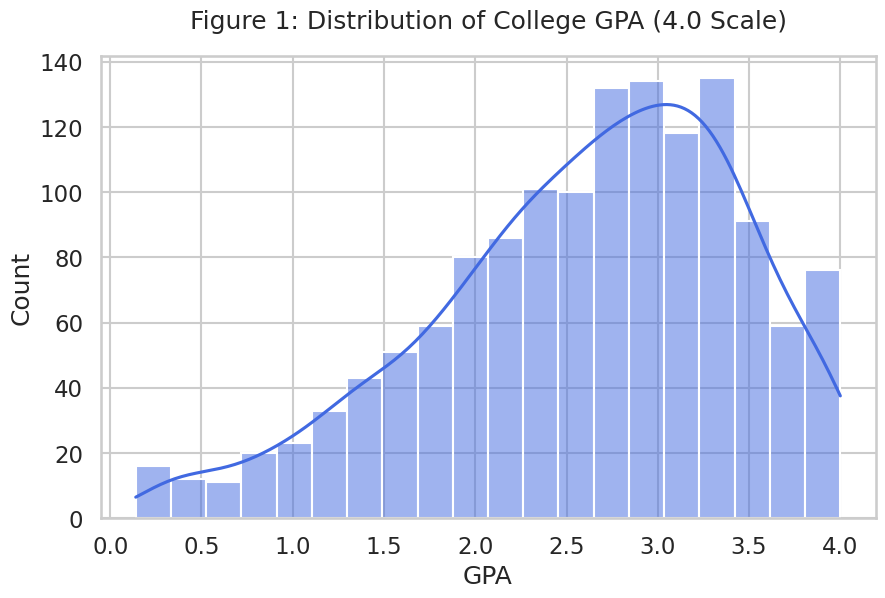

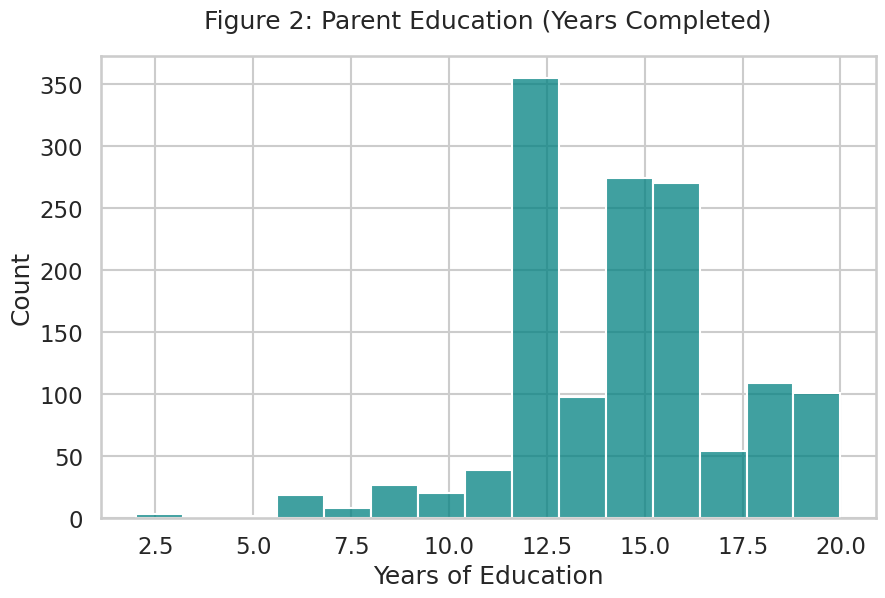

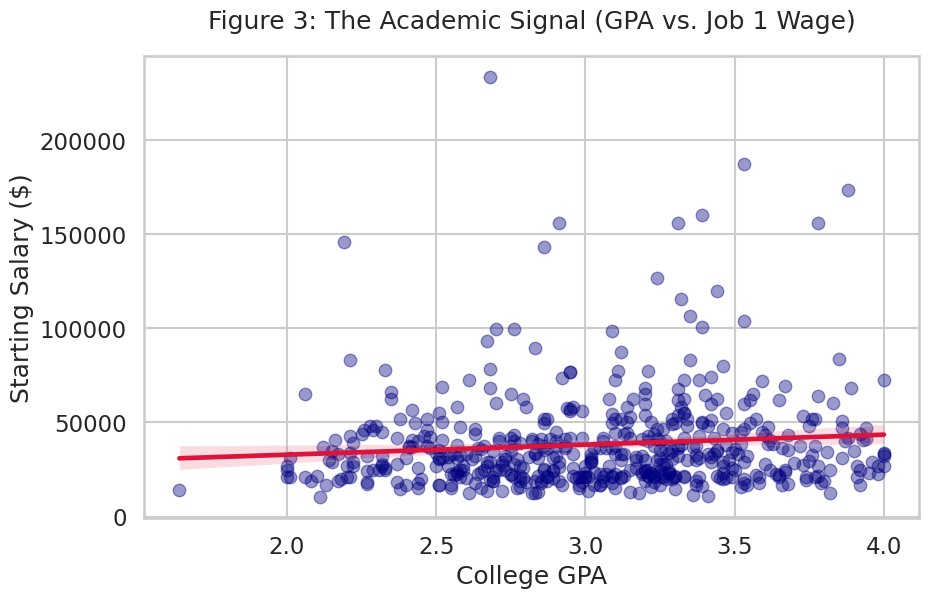

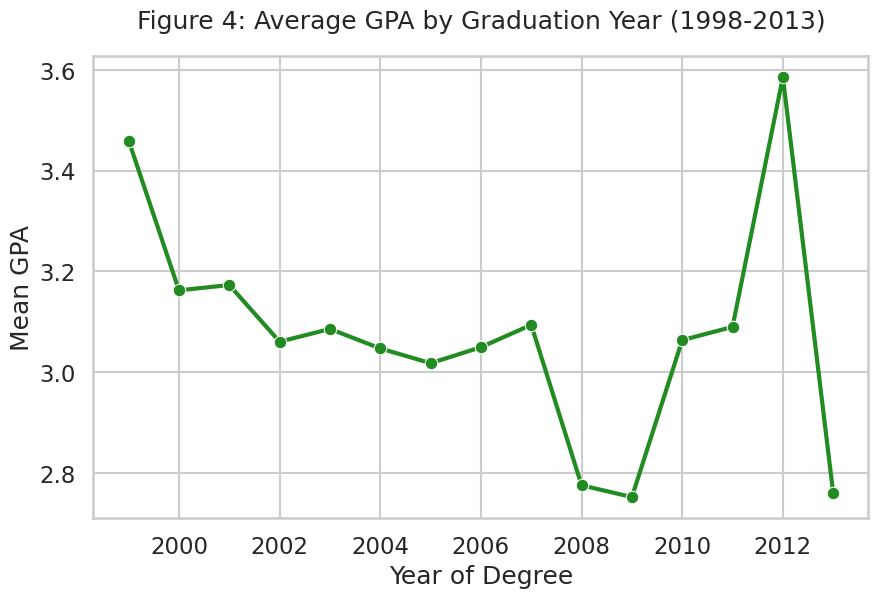

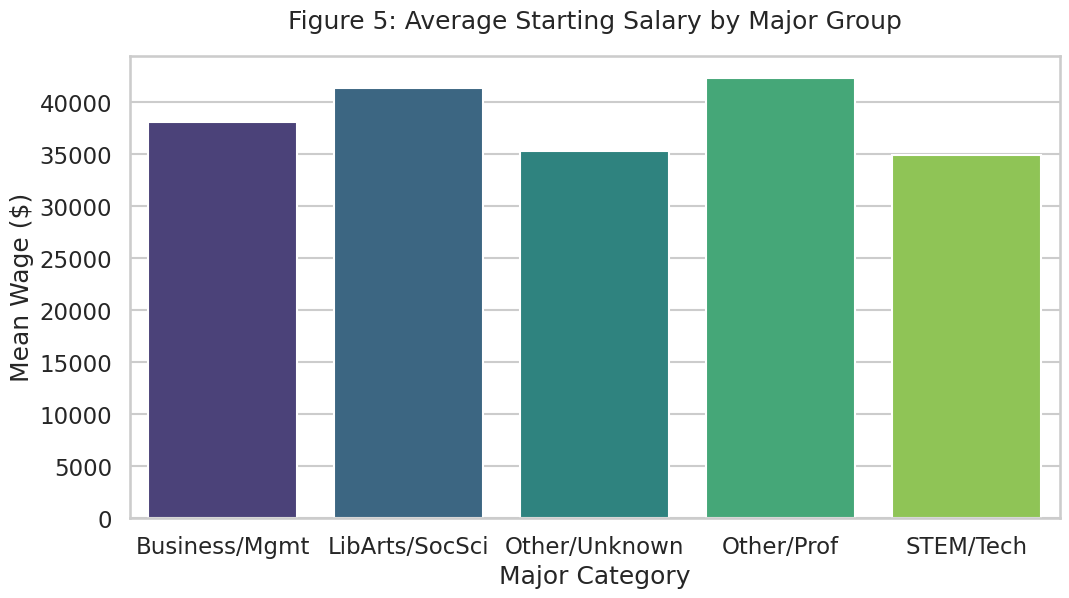

<Figure size 1000x600 with 0 Axes>

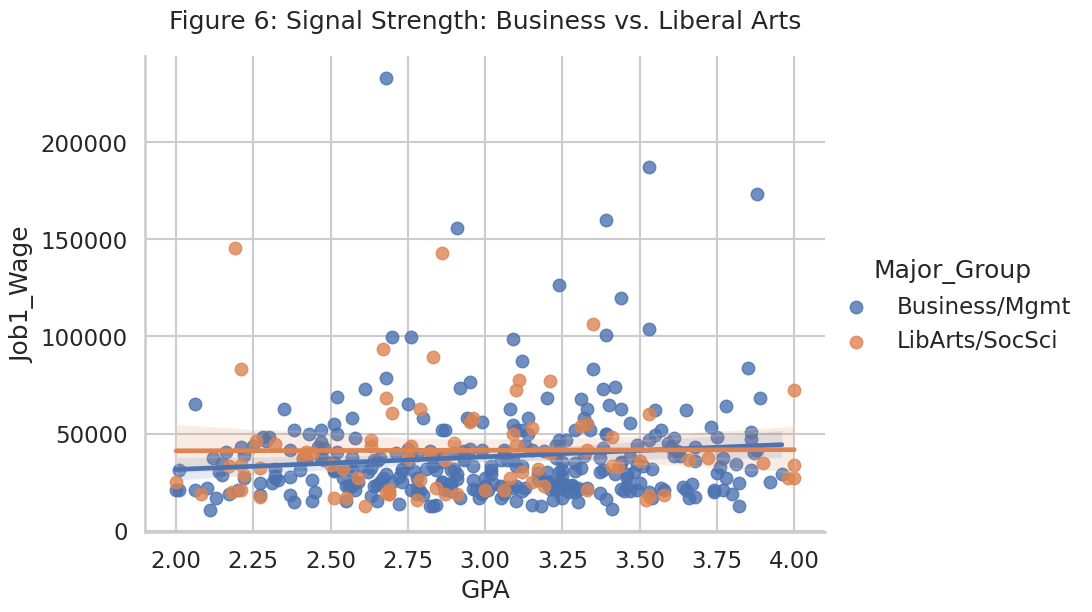

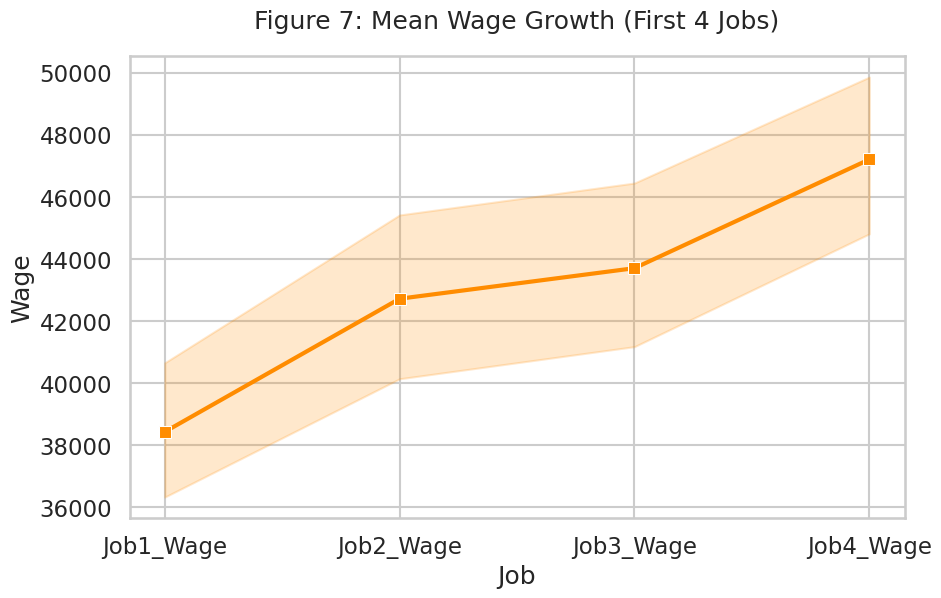

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set professional theme for presentation
sns.set_theme(style="whitegrid", context="talk")

# 1. CLEANED GPA DISTRIBUTION
plt.figure(figsize=(10, 6))
sns.histplot(master_df_categorical['GPA'].dropna(), bins=20, kde=True, color='royalblue')
plt.title('Figure 1: Distribution of College GPA (4.0 Scale)', pad=20)
plt.xlabel('GPA')
plt.savefig('1_gpa_dist.png', bbox_inches='tight')

# 2. CLEANED PARENT EDUCATION
plt.figure(figsize=(10, 6))
sns.histplot(master_df_categorical['Parent_Highest_Grade'].dropna(), bins=15, color='teal')
plt.title('Figure 2: Parent Education (Years Completed)', pad=20)
plt.xlabel('Years of Education')
plt.savefig('2_parent_edu.png', bbox_inches='tight')

# 3. CORE SIGNAL: GPA VS STARTING SALARY
plt.figure(figsize=(10, 6))
sns.regplot(data=master_df_categorical, x='GPA', y='Job1_Wage',
            scatter_kws={'alpha':0.4, 'color':'navy'}, line_kws={'color':'crimson'})
plt.title('Figure 3: The Academic Signal (GPA vs. Job 1 Wage)', pad=20)
plt.xlabel('College GPA')
plt.ylabel('Starting Salary ($)')
plt.savefig('3_signal_scatter.png', bbox_inches='tight')

# 4. GPA INFLATION TREND (NEW)
plt.figure(figsize=(10, 6))
inflation = master_df_categorical.groupby('Degree_Date')['GPA'].mean().reset_index()
sns.lineplot(data=inflation, x='Degree_Date', y='GPA', marker='o', linewidth=3, color='forestgreen')
plt.title('Figure 4: Average GPA by Graduation Year (1998-2013)', pad=20)
plt.xlabel('Year of Degree')
plt.ylabel('Mean GPA')
plt.savefig('4_inflation_trend.png', bbox_inches='tight')

# 5. SALARY BY MAJOR CATEGORY
plt.figure(figsize=(12, 6))
sns.barplot(data=master_df_categorical, x='Major_Group', y='Job1_Wage', palette='viridis', errorbar=None)
plt.title('Figure 5: Average Starting Salary by Major Group', pad=20)
plt.xlabel('Major Category')
plt.ylabel('Mean Wage ($)')
plt.savefig('5_wage_major.png', bbox_inches='tight')

# 6. SIGNAL STRENGTH BY MAJOR (NEW - Interaction Plot)
# Comparing the two biggest groups
subset = master_df_categorical[master_df_categorical['Major_Group'].isin(['Business/Mgmt', 'LibArts/SocSci'])]
plt.figure(figsize=(10, 6))
sns.lmplot(data=subset, x='GPA', y='Job1_Wage', hue='Major_Group', aspect=1.5, height=6)
plt.title('Figure 6: Signal Strength: Business vs. Liberal Arts', pad=20)
plt.savefig('6_signal_comparison.png', bbox_inches='tight')

# 7. WAGE GROWTH OVER TIME (NEW)
wage_vars = ['Job1_Wage', 'Job2_Wage', 'Job3_Wage', 'Job4_Wage']
melted = master_df_categorical.melt(id_vars=['PUBID'], value_vars=wage_vars, var_name='Job', value_name='Wage')
plt.figure(figsize=(10, 6))
sns.lineplot(data=melted, x='Job', y='Wage', marker='s', color='darkorange', linewidth=3)
plt.title('Figure 7: Mean Wage Growth (First 4 Jobs)', pad=20)
plt.savefig('7_wage_growth.png', bbox_inches='tight')

plt.show()

In [ ]:
import statsmodels.formula.api as smf
import pandas as pd

# 1. We create a fresh copy for the regression to avoid 'SettingWithCopy' warnings
reg_df = master_df_categorical.copy() # Changed from master_df.copy() to master_df_categorical.copy()

# 2. Convert Major to a categorical string so the regression understands it
reg_df['Major'] = reg_df['Major'].astype(str)

# 3. Handle the Missing Data (important for statsmodels)
# This ensures all three models are run on the EXACT same people
cols_needed = ['Job1_Wage', 'GPA', 'Parent_Highest_Grade', 'Degree_Date', 'Major', 'Major_Group'] # Added 'Major_Group'
reg_df = reg_df.dropna(subset=cols_needed)

# --- MODEL 1: The Raw Signal ---
model1 = smf.ols('Job1_Wage ~ GPA', data=reg_df).fit()

# --- MODEL 2: Adding Family Background ---
model2 = smf.ols('Job1_Wage ~ GPA + Parent_Highest_Grade', data=reg_df).fit()

# --- MODEL 3: The Interaction (Inflation Angle) ---
# This tests if the value of GPA changes as Degree_Date increases
model3 = smf.ols('Job1_Wage ~ GPA * Degree_Date + Parent_Highest_Grade + C(Major)', data=reg_df).fit()

# --- DISPLAY RESULTS ---
print("--- MODEL 1 RESULTS ---")
display(model1.summary().tables)

print("\n--- MODEL 2 RESULTS ---")
display(model2.summary().tables)

print("\n--- MODEL 3 RESULTS ---")
display(model3.summary().tables)

--- MODEL 1 RESULTS ---


[<class 'statsmodels.iolib.table.SimpleTable'>,
 <class 'statsmodels.iolib.table.SimpleTable'>,
 <class 'statsmodels.iolib.table.SimpleTable'>]


--- MODEL 2 RESULTS ---


[<class 'statsmodels.iolib.table.SimpleTable'>,
 <class 'statsmodels.iolib.table.SimpleTable'>,
 <class 'statsmodels.iolib.table.SimpleTable'>]


--- MODEL 3 RESULTS ---


[<class 'statsmodels.iolib.table.SimpleTable'>,
 <class 'statsmodels.iolib.table.SimpleTable'>,
 <class 'statsmodels.iolib.table.SimpleTable'>]

In [ ]:
# This will print the actual tables you can read
print("--- MODEL 1: RAW SIGNAL ---")
print(model1.summary())

print("\n\n--- MODEL 2: WITH CONTROLS ---")
print(model2.summary())

print("\n\n--- MODEL 3: INFLATION & MAJOR ---")
print(model3.summary())

--- MODEL 1: RAW SIGNAL ---
                            OLS Regression Results                            
Dep. Variable:              Job1_Wage   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     5.833
Date:                Sun, 03 May 2026   Prob (F-statistic):             0.0161
Time:                        23:45:34   Log-Likelihood:                -5930.7
No. Observations:                 513   AIC:                         1.187e+04
Df Residuals:                     511   BIC:                         1.187e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2.133e+04   

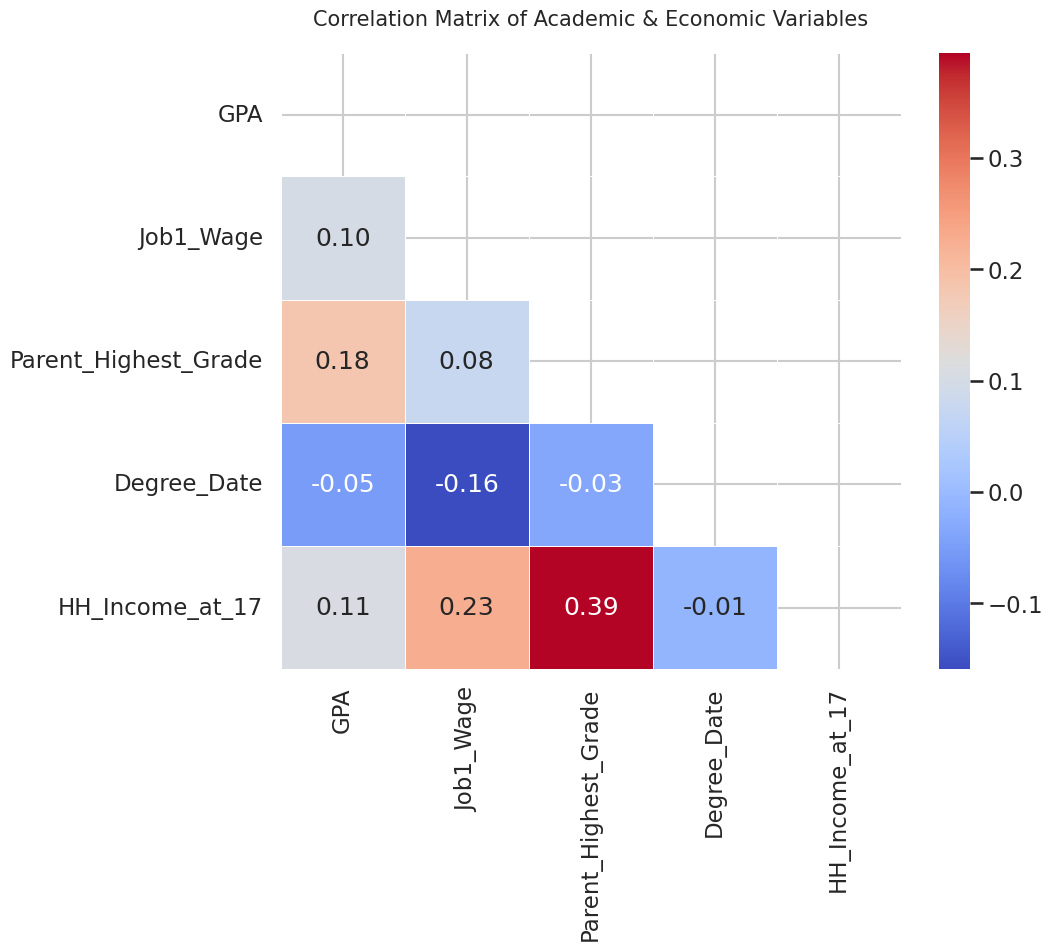

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Select the key numeric variables for the matrix
# We use the numeric master_df here
corr_cols = ['GPA', 'Job1_Wage', 'Parent_Highest_Grade', 'Degree_Date', 'HH_Income_at_17']
corr_data = master_df[corr_cols]

# 2. Calculate the correlation matrix
corr_matrix = corr_data.corr()

# 3. Create a Heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # This masks the top half for a cleaner "triangle" look

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,          # Shows the actual numbers in the boxes
            cmap='coolwarm',     # Red for positive correlation, Blue for negative
            fmt=".2f",           # Round to 2 decimal places
            linewidths=0.5)

plt.title('Correlation Matrix of Academic & Economic Variables', fontsize=15, pad=20)
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import statsmodels.formula.api as smf

# 1. Ensure the data is ready and clean
# We use the categorical df to make sure we have the labels for Race if needed
# Note: 'HH_Income_at_17' is the variable for household income from your progress report
reg_df = master_df_categorical.dropna(subset=['Job1_Wage', 'GPA', 'Parent_Highest_Grade', 'HH_Income_at_17', 'Degree_Date', 'Major_Group']) # Added Major_Group to dropna subset

In [ ]:
import statsmodels.formula.api as smf

# 1. Filter for Business Majors only
# Note: Check if your 'Major' column uses 102.0 or if you have a 'Major_Group' column
biz_df = reg_df[reg_df['Major_Group'] == 'Business/Mgmt'].copy()

# If your filter returns 0 rows, use the numeric code from your previous table:
if len(biz_df) == 0:
    biz_df = reg_df[reg_df['Major'] == 102.0].copy()

# 2. Run the Full Interaction Model for this specific subgroup
# We remove C(Major) since everyone is now in the same major group
model_biz = smf.ols('Job1_Wage ~ GPA * Degree_Date + C(Race_Ethnicity) + Parent_Highest_Grade + HH_Income_at_17',
                    data=biz_df).fit()

# 3. Display Results
print(f"--- MODEL: BUSINESS MAJORS ONLY (N={len(biz_df)}) ---")
print(f"R-squared: {model_biz.rsquared:.4f}")
display(model_biz.summary())

--- MODEL: BUSINESS MAJORS ONLY (N=247) ---
R-squared: 0.0827


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Job1_Wage   R-squared:                       0.083
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     2.682
Date:                Sun, 03 May 2026   Prob (F-statistic):            0.00769
Time:                        23:45:45   Log-Likelihood:                -2845.6
No. Observations:                 247   AIC:                             5709.
Df Residuals:                     238   BIC:                             5741.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept               1.086e+05   8.93e+06      0.012      0.990   -1.75e+07    1.77e+07
C(Race_Ethnicity)[T.2]  3833.0969   6413.498      0.598      0.551   -8801.377    1.65e+04
C(Race_Ethnicity)[T.3]  4108.0096   2.53e+04      0.163      0.871   -4.57e+04    5.39e+04
C(Race_Ethnicity)[T.4]  5026.6445   5032.618      0.999      0.319   -4887.519    1.49e+04
GPA                     1.464e+06   2.93e+06      0.499      0.618   -4.31e+06    7.24e+06
Degree_Date              -48.6717   4451.942     -0.011      0.991   -8818.915    8721.571
GPA:Degree_Date         -728.7566   1462.298     -0.498      0.619   -3609.457    2151.944
Parent_Highest_Grade     528.6614    651.531      0.811      0.418    -754.842    1812.165
HH_Income_at_17            0.0655      0.038      1.715      0.088      -0.010       0.141
==============================================================================
Omnibus:                      224.389   Durbin-Watson:                   1.807
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4587.199
Skew:                           3.613   Prob(JB):                         0.00
Kurtosis:                      22.837   Cond. No.                     4.94e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.94e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# --- INFLATION ADJUSTMENT (to 2020 dollars approx) ---
# Simple CPI index (you can refine later if needed)
cpi_dict = {
    1999: 166.6, 2000: 172.2, 2001: 177.1, 2002: 179.9,
    2003: 184.0, 2004: 188.9, 2005: 195.3, 2006: 201.6,
    2007: 207.3, 2008: 215.3, 2009: 214.5, 2010: 218.1,
    2011: 224.9, 2012: 229.6, 2013: 233.0
}

# Convert wage to real terms
master_df_categorical['CPI'] = master_df_categorical['Job1_Year'].map(cpi_dict)

# Normalize to 2013 dollars
base_cpi = 233.0

master_df_categorical['Real_Wage'] = (
    master_df_categorical['Job1_Wage'] * (base_cpi / master_df_categorical['CPI'])
)

In [ ]:
import numpy as np

master_df_categorical['ln_Wage'] = np.log(master_df_categorical['Real_Wage'])

In [ ]:
gpa_trend = master_df_categorical.groupby('Degree_Date')['GPA'].mean().reset_index()

print(gpa_trend)

    Degree_Date       GPA
0          1999  3.460000
1          2000  3.162500
2          2001  3.173077
3          2002  3.060476
4          2003  3.085873
5          2004  3.047215
6          2005  3.017822
7          2006  3.049615
8          2007  3.094000
9          2008  2.775405
10         2009  2.752000
11         2010  3.063636
12         2011  3.090000
13         2012  3.586000
14         2013  2.760000


In [ ]:
gpa_major = master_df_categorical.groupby('Major_Group')['GPA'].mean().sort_values()

print(gpa_major)

Major_Group
LibArts/SocSci    2.922073
Business/Mgmt     3.003636
STEM/Tech         3.047647
Other/Unknown     3.182600
Other/Prof        3.333590
Name: GPA, dtype: float64


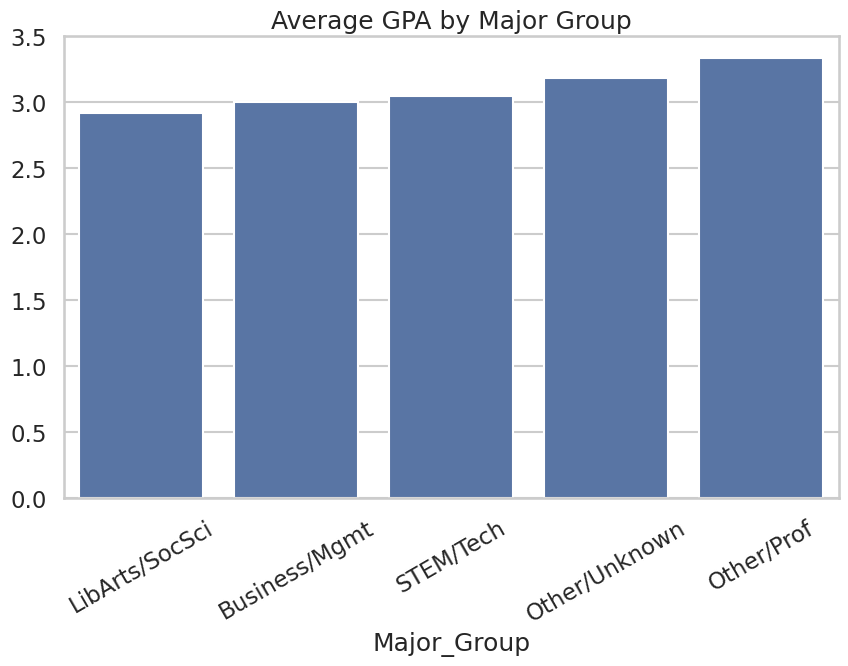

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=gpa_major.index, y=gpa_major.values)
plt.title("Average GPA by Major Group")
plt.xticks(rotation=30)
plt.show()

In [ ]:
import statsmodels.formula.api as smf

# Clean dataset
reg_df = master_df_categorical.copy()

reg_df = reg_df.dropna(subset=[
    'Real_Wage', 'ln_Wage', 'GPA',
    'Parent_Highest_Grade', 'Major_Group'
])

# --- REAL WAGE MODELS ---
m1 = smf.ols('Real_Wage ~ GPA', data=reg_df).fit()

m2 = smf.ols('Real_Wage ~ GPA + Parent_Highest_Grade', data=reg_df).fit()

m3 = smf.ols('Real_Wage ~ GPA + Parent_Highest_Grade + C(Major_Group)', data=reg_df).fit()

# --- LOG WAGE MODELS (THIS IS YOUR BEST SPEC) ---
m1_log = smf.ols('ln_Wage ~ GPA', data=reg_df).fit()

m2_log = smf.ols('ln_Wage ~ GPA + Parent_Highest_Grade', data=reg_df).fit()

m3_log = smf.ols('ln_Wage ~ GPA + Parent_Highest_Grade + C(Major_Group)', data=reg_df).fit()

# PRINT RESULTS
print("=== REAL WAGE MODELS ===")
print(m1.summary())
print(m2.summary())
print(m3.summary())

print("\n=== LOG WAGE MODELS (MAIN RESULT) ===")
print(m1_log.summary())
print(m2_log.summary())
print(m3_log.summary())

=== REAL WAGE MODELS ===
                            OLS Regression Results                            
Dep. Variable:              Real_Wage   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     7.113
Date:                Sun, 03 May 2026   Prob (F-statistic):            0.00790
Time:                        23:58:15   Log-Likelihood:                -5864.3
No. Observations:                 508   AIC:                         1.173e+04
Df Residuals:                     506   BIC:                         1.174e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2.286e+04   708

In [ ]:
# --- GPA SIGNAL OVER TIME (TEST FOR INFLATION) ---
m_inflation = smf.ols(
    'ln_Wage ~ GPA * Degree_Date + Parent_Highest_Grade + C(Major_Group)',
    data=reg_df.dropna(subset=['Degree_Date'])
).fit()

print("\n=== GPA x GRAD YEAR (INFLATION TEST) ===")
print(m_inflation.summary())


=== GPA x GRAD YEAR (INFLATION TEST) ===
                            OLS Regression Results                            
Dep. Variable:                ln_Wage   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     5.389
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.61e-06
Time:                        23:58:39   Log-Likelihood:                -343.42
No. Observations:                 508   AIC:                             704.8
Df Residuals:                     499   BIC:                             742.9
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------